In [1]:
# Autoreload custom modules
%load_ext autoreload
%autoreload 2

In [ ]:
import sys, os

import pandas as pd
import json

import numpy as np
import jax
import jax.numpy as jnp
import optax

import time
import importlib
import matplotlib.pyplot as plt

In [3]:
# import custom modules
sys.path.append('..')
from models.models import DecoderOnlyTransformer
from util.data_loader import load_data, encode, decode, get_batch
from util.optimization import train_step, loss_and_metrics, create_train_state

In [4]:
# initialize jax random key
key = jax.random.key(0)

In [5]:
# load dataset
train_data, test_data, ctoi, itoc, vocab_size = load_data(encoded_path='../data/encoded.pkl')

##### Create Model

In [6]:
# Define architecture parameters sweep
arch_configs = [
    {'d_model': 128, 'n_layers': 2, 'n_heads': 2}, # Small model
    {'d_model': 256, 'n_layers': 4, 'n_heads': 4}, # Medium model
    {'d_model': 256, 'n_layers': 6, 'n_heads': 8}, # Large model
    {'d_model': 512, 'n_layers': 6, 'n_heads': 8}, # Extra Large model --> Takes too long to train so not included in results
]

In [ ]:
# Define base hyperparameters
B, T = 128, 64 # Batch size and sequence length
learning_rate = 1e-3
niter = 50000 # Small number of iterations for experimentation
results = []

In [ ]:
# Train loop

cur_iter = 0
start_time = time.time() # Should you have put this in the for loop
for cfg in arch_configs:
    d_model = cfg['d_model']
    n_layers = cfg['n_layers']
    n_heads = cfg['n_heads']

    print(f"Training model with d_model={d_model}, n_layers={n_layers}, n_heads={n_heads}")

    while True:
        if cur_iter == 0:
            # initialize model for current architecture
            model, params = create_train_state(key, vocab_size=vocab_size, d_model=d_model, n_layers=n_layers, n_heads=n_heads, max_len=T)

            # Create Adam optimizer
            tx = optax.adam(learning_rate)
            # initialize training state
            opt_state = tx.init(params)
            print(f'Initialized Optimizer: Adam with learning rate {learning_rate}')

            # Create empty lists for storing metrics
            cfg_loss_history = []
            cfg_time_history = []
            cfg_test_loss_history = []
            cfg_test_time_history = []

        input, target = get_batch(train_data, B, T)
        # perform a training step
        params_new, opt_state_new, metrics = train_step(model, params, opt_state, input, target, tx)

        # uodate params and opt_state
        params = params_new
        opt_state = opt_state_new
        # get metrics
        acc = metrics['acc']
        acc_last = metrics['acc_last']
        loss = metrics['loss']

        # append to history
        cfg_loss_history.append(loss)
        cfg_time_history.append(time.time() - start_time)

        # Evaluate on test set regularly
        if cur_iter % (niter // 50) == 0 or cur_iter == niter - 1:
            time_since_start = time.time() - start_time
            B_test, T_test = 1024, 64 # larger batch size for evaluation
            test_input, test_target = get_batch(test_data, B_test, T_test)
            test_logits = model.apply({'params': params}, test_input)
            test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
            test_acc = test_metrics['acc']
            test_acc_last = test_metrics['acc_last']
            cfg_test_loss_history.append(test_loss)
            cfg_test_time_history.append(time_since_start)
            print(f"iteration {cur_iter:_}  time: {time_since_start:.1f} seconds")
            print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
            print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
            print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
            print()

        cur_iter += 1
        if cur_iter >= niter:
            # store history for this config
            results.append({
                'config': cfg,
                'train_loss_history': cfg_loss_history,
                'train_time_history': cfg_time_history,
                'test_loss_history': cfg_test_loss_history,
                'test_time_history': cfg_test_time_history,
            })
            cur_iter = 0
            break





Training model with d_model=128, n_layers=2, n_heads=2
Initialized Optimizer: Adam with learning rate 0.001
iteration 0  time: 9.6 seconds
	 	 loss(train :: test): 4.1500 :: 3.2900
	 	 accuracy (train :: test): 1.7% :: 14.0%
	 	 accuracy (last character) (train :: test): 3.1% :: 14.8%

iteration 200  time: 14.8 seconds
	 	 loss(train :: test): 2.2334 :: 2.2133
	 	 accuracy (train :: test): 31.9% :: 32.8%
	 	 accuracy (last character) (train :: test): 25.0% :: 31.6%

iteration 400  time: 17.1 seconds
	 	 loss(train :: test): 1.8803 :: 1.8426
	 	 accuracy (train :: test): 41.7% :: 43.9%
	 	 accuracy (last character) (train :: test): 48.4% :: 44.3%

iteration 600  time: 19.4 seconds
	 	 loss(train :: test): 1.6889 :: 1.7239
	 	 accuracy (train :: test): 48.4% :: 47.5%
	 	 accuracy (last character) (train :: test): 46.9% :: 47.8%

iteration 800  time: 21.7 seconds
	 	 loss(train :: test): 1.6013 :: 1.6613
	 	 accuracy (train :: test): 51.6% :: 49.2%
	 	 accuracy (last character) (train :: 

KeyboardInterrupt: 

save results

In [ ]:
os.makedirs("../results", exist_ok=True)

In [ ]:
# Convert JAX arrays to lists
def convert_to_list(obj):
    if isinstance(obj, dict):
        return {k: convert_to_list(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_list(item) for item in obj]
    elif isinstance(obj, jax.numpy.ndarray):
        return obj.tolist() # Convert JAX array to Python list
    else:
        return obj

results_serializable = convert_to_list(results)

with open("../results/model_arch_training_results.json", "w") as f:
    json.dump(results_serializable, f)

analyse results

In [9]:
# load results

with open("../results/model_arch_training_results.json", "r") as f:
    results = json.load(f)

In [10]:
import pandas as pd

records = []
for r in results:
    cfg = r['config']
    d_model = cfg['d_model']
    n_layers = cfg['n_layers']
    n_heads = cfg['n_heads']

    # flatten per config
    for t, loss in zip(r['train_time_history'], r['train_loss_history']):
        records.append({
            'config': f"d{d_model}_L{n_layers}_H{n_heads}",
            'type': 'train',
            'time': t,
            'loss': loss
        })
    for t, loss in zip(r['test_time_history'], r['test_loss_history']):
        records.append({
            'config': f"d{d_model}_L{n_layers}_H{n_heads}",
            'type': 'test',
            'time': t,
            'loss': loss
        })

df = pd.DataFrame(records)

In [11]:
df.head()

,config,type,time,loss
0,d128_L2_H2,train,9.639317,4.150022
1,d128_L2_H2,train,12.710790,3.305652
2,d128_L2_H2,train,12.713136,3.054253
3,d128_L2_H2,train,12.715338,2.951924
4,d128_L2_H2,train,12.717411,2.865325


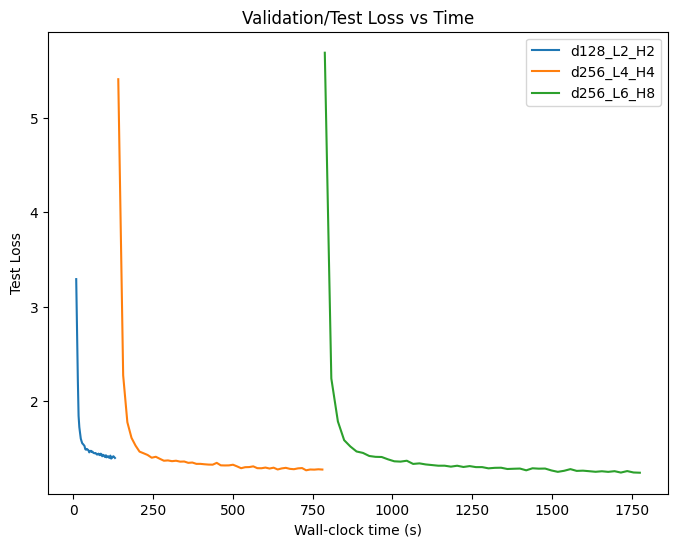

In [12]:
# Plot loss vs time for all configs

plt.figure(figsize=(8,6))
for name, group in df[df['type']=='test'].groupby('config'):
    plt.plot(group['time'], group['loss'], label=name)
plt.xlabel("Wall-clock time (s)")
plt.ylabel("Test Loss")
plt.title("Validation/Test Loss vs Time")
plt.legend()
plt.show()


In [13]:
# Compute key comparison metrics

def area_under_curve(x, y):
    order = np.argsort(x)
    return np.trapezoid(np.array(y)[order], np.array(x)[order])

def time_to_target(x, y, target):
    for t, val in sorted(zip(x, y)):
        if val <= target:
            return t
    return np.nan  # never reached target

summary = []
for cfg, group in df[df['type']=='test'].groupby('config'):
    times, losses = group['time'].values, group['loss'].values
    aul = area_under_curve(times, losses)
    final_loss = losses[-1]
    best_loss = losses.min()
    t_target = time_to_target(times, losses, target=1.4)  # adjust target as needed. 1.4 chosen here since it is the pretty close to the smallest loss achieved by all configs
    summary.append({
        'config': cfg,
        'final_loss': final_loss,
        'best_loss': best_loss,
        'AUL': aul,
        'time_to_target': t_target
    })

summary_df = pd.DataFrame(summary).sort_values('best_loss')
print(summary_df)

       config  final_loss  best_loss          AUL  time_to_target
2  d256_L6_H8    1.241048   1.241048  1372.653036      986.191019
1  d256_L4_H4    1.274656   1.266732   904.964344      246.086927
0  d128_L2_H2    1.397335   1.390864   185.798168      114.337027


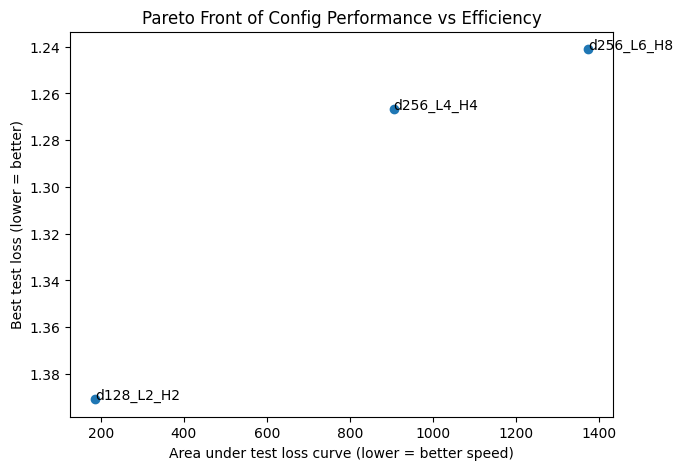

In [14]:
# Parento Frontier Visualization
plt.figure(figsize=(7,5))
plt.scatter(summary_df['AUL'], summary_df['best_loss'])
for _, r in summary_df.iterrows():
    plt.text(r['AUL'], r['best_loss'], r['config'])
plt.xlabel("Area under test loss curve (lower = better speed)")
plt.ylabel("Best test loss (lower = better)")
plt.title("Pareto Front of Config Performance vs Efficiency")
plt.gca().invert_yaxis()
plt.show()

In [15]:
# Compute generalization gap. Quantify overfitting. Lower --> better generalization
train_final = (
    df[df['type']=='train']
    .groupby('config')['loss'].last()
    .rename('train_final')
)
test_final = (
    df[df['type']=='test']
    .groupby('config')['loss'].last()
    .rename('test_final')
)

gaps = (test_final - train_final).reset_index().sort_values(0)
print(gaps)

       config         0
0  d128_L2_H2  0.005445
1  d256_L4_H4  0.040739
2  d256_L6_H8  0.048462
